/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15503/1575868979.py:74: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15503/1575868979.py:74: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15503/1575868979.py:74: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
/var/folders/g5/yynr0rkn6cn28d0cw2spb26w0000gn/T/ipykernel_15503/1575868979.py:74: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities

[INFO] Saved per-subject summary → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block2/block2_posterior_alpha_summary.csv


,subj,group,posterior_alpha_wpli,n_epochs,n_ch_roi
0,001,AD,0.199847,299,5
1,002,AD,0.207710,396,5
2,003,AD,0.249632,153,5
3,004,AD,0.055367,353,5
4,005,AD,0.293074,394,5


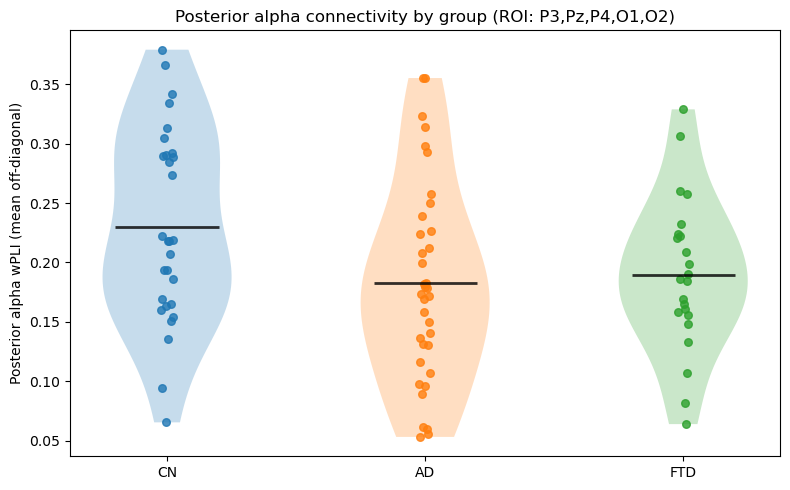

[INFO] Saved violin plot → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/block2/block2_posterior_alpha_violin.png
[INFO] Block 2 complete.


In [5]:
# ===========================
# Block 2 — Posterior Alpha Connectivity (wPLI), Hypothesis 1
# ===========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne_connectivity import spectral_connectivity_epochs  # we confirmed this exists

# -----------------
# Config
# -----------------

# root of the study folder (you already told me this path)
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")

# where the cleaned .set live, one sub-xxx folder each under outputs/
DATA_ROOT = ROOT / "outputs"

# where we will write Block 2 results now
OUTDIR = ROOT / "outputs" / "connectivity" / "block2"
OUTDIR.mkdir(parents=True, exist_ok=True)

# participants.tsv path
PARTIC = ROOT / "participants.tsv"  # you showed me columns: participant_id, Gender, Age, Group, MMSE

# band of interest
ALPHA_FMIN, ALPHA_FMAX = 8.0, 13.0
METHOD = "wpli"  # Weighted Phase Lag Index

# epoch parameters
EPOCH_LEN = 2.0    # seconds
PICKS_ROI = ["P3", "Pz", "P4", "O1", "O2"]  # posterior/parietal-occipital ROI

# group order / labels
GROUP_MAP = {
    "C": "CN",   # control / cognitively normal
    "A": "AD",   # Alzheimer's disease
    "F": "FTD",  # frontotemporal dementia
}
GROUP_ORDER = ["CN", "AD", "FTD"]


# -----------------
# Helpers
# -----------------

def load_group_table(participants_path: Path) -> dict:
    """
    Read participants.tsv and build dict: '001' -> 'CN' / 'AD' / 'FTD'
    """
    dfp = pd.read_csv(participants_path, sep="\t")
    # participant_id is like 'sub-001'
    dfp["sub_id_core"] = dfp["participant_id"].str.replace("^sub-", "", regex=True)

    # the column with diagnostic group is "Group" in your file.
    # Map 'C','A','F' -> readable strings
    dfp["group_pretty"] = dfp["Group"].map(GROUP_MAP)

    return dict(zip(dfp["sub_id_core"], dfp["group_pretty"]))


def epochs_for_subject(set_path: Path, picks: list[str], epoch_len_s: float):
    """
    Load one subject's cleaned EEGLAB .set, pick ROI channels,
    cut into fixed-length non-overlapping 2 s epochs.

    Returns:
        epochs_roi (mne.Epochs)
    """
    # load cleaned final .set
    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)

    # rename legacy T3/T4/T5/T6 etc. if present so montage works and picks resolve
    rename_map = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
    present = {old: new for old, new in rename_map.items() if old in raw.ch_names}
    if len(present) > 0:
        raw.rename_channels(present)

    # attach standard montage so channels get xyz locations (needed for head plots later)
    try:
        raw.set_montage("standard_1020", match_case=False)
    except Exception as e:
        print(f"[WARN] montage set failed for {set_path.name}: {e}")

    # now pick just ROI channels
    picks_here = [ch for ch in picks if ch in raw.ch_names]
    if len(picks_here) < 2:
        return None, picks_here  # too few channels to form connectivity

    raw_roi = raw.copy().pick(picks_here)

    sfreq = raw_roi.info["sfreq"]

    # Build fake events every epoch_len_s so we can use Epochs easily
    n_samples = raw_roi.n_times
    seglen = int(round(epoch_len_s * sfreq))

    # cut into consecutive non-overlapping windows
    onsets = np.arange(0, n_samples - seglen + 1, seglen, dtype=int)
    n_epochs = len(onsets)
    if n_epochs < 2:
        return None, picks_here  # basically no data

    # events array: shape (n_epochs, 3) => [onset, 0, event_id]
    events = np.c_[onsets, np.zeros(n_epochs, dtype=int), np.ones(n_epochs, dtype=int)]

    epochs_roi = mne.Epochs(
        raw_roi,
        events=events.astype(int),
        event_id={"dummy": 1},
        tmin=0.0,
        tmax=epoch_len_s - 1.0 / sfreq,
        baseline=None,
        preload=True,
        reject=None,
        verbose=False,
    )

    return epochs_roi, picks_here


def compute_wpli_matrix(epochs_obj, fmin, fmax, method="wpli"):
    """
    Compute wPLI in [fmin,fmax] for all channel pairs in these epochs.
    Returns (n_ch, n_ch) dense matrix.
    """
    data = epochs_obj.get_data()  # (n_epochs, n_ch, n_times)

    conn = spectral_connectivity_epochs(
        data,
        method=method,
        sfreq=epochs_obj.info["sfreq"],
        fmin=fmin,
        fmax=fmax,
        faverage=True,    # average over alpha band to get 1 number per pair
        verbose=False,
    )

    # mne_connectivity returns a Connectivity object
    # get dense 2D (ch,ch) or (ch,ch,1); we'll squeeze.
    mat = conn.get_data(output="dense")
    mat = np.squeeze(mat)  # (n_ch, n_ch)

    return mat


def mean_offdiag(mat2d: np.ndarray) -> float:
    """
    Mean of off-diagonal connectivity entries.
    """
    n = mat2d.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(mat2d[mask].mean())


def edges_above_subject_mean(mat2d: np.ndarray, ch_names: list[str]):
    """
    For this subject:
    - get that subject's own mean connectivity across all off-diagonals
    - keep only edges strictly above that mean
    - return list of dict rows (src, dst, weight)
    We'll combine these across subjects within each group later.
    """
    n = mat2d.shape[0]
    mask = ~np.eye(n, dtype=bool)
    subj_mean = float(mat2d[mask].mean())

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            w = float(mat2d[i, j])
            if w > subj_mean:
                rows.append({
                    "src": ch_names[i],
                    "dst": ch_names[j],
                    "weight": w,
                })
    return rows


# -----------------
# Main loop over subjects
# -----------------

group_lookup = load_group_table(PARTIC)

rows = []                # per-subject biomarker rows for summary CSV / stats
group_all_mats = {}      # group -> list of (n_ch x n_ch) matrices for averaging
group_all_edges = {}     # group -> list of rows of strong edges from edges_above_subject_mean

# We'll scan sub-* folders under ROOT/outputs just like you showed (sub-001, sub-002, ...)
for sub_dir in sorted(DATA_ROOT.glob("sub-*")):
    # subject core id, e.g. "001"
    sub_id_core = sub_dir.name.replace("sub-", "")

    # figure out group label for this subject using participants.tsv
    if sub_id_core not in group_lookup:
        # skip if we can't map this subject to CN/AD/FTD
        print(f"[WARN] cannot determine group for {sub_dir.name}, skip.")
        continue
    group_code = group_lookup[sub_id_core]  # "CN" / "AD" / "FTD"

    # expect something like sub-001_v2.1_cleaned_final.set in that folder
    set_files = sorted(sub_dir.glob("*cleaned_final.set"))
    if len(set_files) == 0:
        print(f"[WARN] {sub_dir.name}: no *_cleaned_final.set, skip.")
        continue
    set_path = set_files[0]

    # get 2s epochs for posterior ROI only
    epochs_roi, picks_here = epochs_for_subject(set_path, PICKS_ROI, EPOCH_LEN)

    if epochs_roi is None or len(epochs_roi) < 2:
        # not enough usable data
        print(f"[WARN] {sub_dir.name}: not enough usable epochs, skip.")
        continue

    # compute wPLI matrix for this ROI
    mat = compute_wpli_matrix(
        epochs_roi,
        fmin=ALPHA_FMIN,
        fmax=ALPHA_FMAX,
        method=METHOD
    )

    # safety check shape
    if mat.ndim != 2 or mat.shape[0] < 2 or mat.shape[0] != mat.shape[1]:
        print(f"[WARN] {sub_dir.name}: bad wPLI matrix shape {mat.shape}, skip.")
        continue

    # this subject's scalar posterior-alpha connectivity (mean off-diagonal)
    biomarker_val = mean_offdiag(mat)

    # append per-subject summary row
    rows.append({
        "subj": sub_id_core,
        "group": group_code,
        "posterior_alpha_wpli": biomarker_val,
        "n_epochs": len(epochs_roi),
        "n_ch_roi": len(picks_here),
    })

    # save each subject matrix individually if you want per-subject debug
    np.save(
        OUTDIR / f"{sub_dir.name}_posterior_alpha_wpli.npy",
        mat
    )

    # store matrix in that group's list (for group mean map later)
    group_all_mats.setdefault(group_code, []).append(mat)

    # get strong edges for this subject (above subject mean)
    edge_rows = edges_above_subject_mean(mat, picks_here)
    group_all_edges.setdefault(group_code, []).extend(edge_rows)


# -----------------
# Save the per-subject summary table
# -----------------
df_block2 = pd.DataFrame(rows)

summary_csv_path = OUTDIR / "block2_posterior_alpha_summary.csv"
df_block2.to_csv(summary_csv_path, index=False)
print(f"[INFO] Saved per-subject summary → {summary_csv_path}")

# quick peek in notebook
display(df_block2.head())


# -----------------
# Make group-level violin / scatter figure
# -----------------
# build list of arrays [CN_vals, AD_vals, FTD_vals] in that order:
vals_by_group = []
colors = []

palette = {
    "CN": "#1f77b4",   # blue-ish
    "AD": "#ff7f0e",   # orange-ish
    "FTD": "#2ca02c",  # green-ish
}

for g in GROUP_ORDER:
    these_vals = df_block2.loc[df_block2["group"] == g, "posterior_alpha_wpli"].dropna().values
    vals_by_group.append(these_vals)
    colors.append(palette.get(g, "gray"))

fig, ax = plt.subplots(figsize=(8,5))

# violin (distribution shape) per group
parts = ax.violinplot(
    vals_by_group,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# color + transparency
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c)
    pc.set_alpha(0.25)
    pc.set_edgecolor('none')

# also plot actual subject dots + horizontal group mean
for i, (grp, arr) in enumerate(zip(GROUP_ORDER, vals_by_group), start=1):
    if len(arr) == 0:
        continue
    ax.scatter(
        np.full_like(arr, i, dtype=float) + (np.random.rand(len(arr))-0.5)*0.05,
        arr,
        color=palette.get(grp, "gray"),
        s=30,
        alpha=0.8,
        zorder=3
    )
    ax.hlines(
        y=np.mean(arr),
        xmin=i-0.2,
        xmax=i+0.2,
        color="black",
        linewidth=2,
        alpha=0.8,
        zorder=4
    )

ax.set_xticks([1,2,3])
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel("Posterior alpha wPLI (mean off-diagonal)")
ax.set_title("Posterior alpha connectivity by group (ROI: P3,Pz,P4,O1,O2)")

fig.tight_layout()

violin_path = OUTDIR / "block2_posterior_alpha_violin.png"
fig.savefig(violin_path, dpi=300)
plt.show()
print(f"[INFO] Saved violin plot → {violin_path}")


# -----------------
# Save group-average matrices later head-map plotting
# -----------------
for grp_code, mats in group_all_mats.items():
    if len(mats) == 0:
        continue

    mats_arr = np.stack(mats, axis=0)  # shape (n_subj_grp, n_ch, n_ch)
    grp_mean_mat = mats_arr.mean(axis=0)

    # save the group average posterior wPLI matrix
    np.save(
        OUTDIR / f"group_{grp_code}_posterior_alpha_wpli_mean.npy",
        grp_mean_mat
    )

print("[INFO] Block 2 complete.")


[Classical ANOVA]
    Source        SS  DF        MS         F     p-unc       np2
0   group  0.039622   2  0.019811  3.202418  0.045616  0.070071
1  Within  0.525830  85  0.006186       NaN       NaN       NaN

[Pairwise comparisons]
   Contrast   A    B  Paired  Parametric         T        dof alternative  \
0    group  AD   CN   False        True -2.300432  60.923231   two-sided   
1    group  AD  FTD   False        True -0.359837  55.042284   two-sided   
2    group  CN  FTD   False        True  2.001214  49.999360   two-sided   

      p-unc    p-corr p-adjust   BF10     cohen  
0  0.024862  0.074586     bonf  2.294 -0.571775  
1  0.720346  1.000000     bonf  0.285 -0.090569  
2  0.050812  0.152436     bonf  1.411  0.543930  

Descriptive stats:
            mean       std  count
group                           
AD     0.182599  0.084333     36
CN     0.230076  0.081383     29
FTD    0.189597  0.064476     23


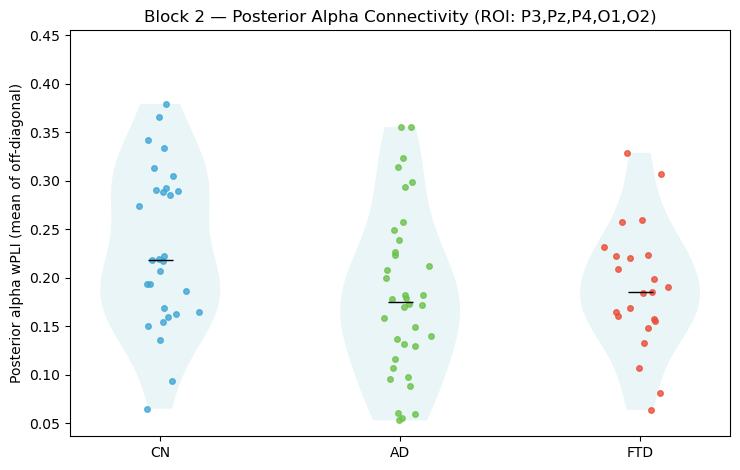

[i] Figure saved: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_posterior_alpha_stats_violin.png
[i] ANOVA: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_posterior_alpha_ANOVA.csv
[i] Pairwise: /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_posterior_alpha_pairwise.csv


In [6]:
# =====================================================
# Block 2: Group Statistics — Posterior Alpha Connectivity
# =====================================================
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "block2" / "block2_posterior_alpha_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
merged = pd.read_csv(IN_CSV)
merged.rename(columns={"posterior_alpha_wpli": "global_wpli"}, inplace=True)

# ---------- ANOVA ----------
anova_res = pg.anova(data=merged, dv="global_wpli", between="group", detailed=True)
anova_path = SAVE_DIR / "block2_posterior_alpha_ANOVA.csv"
anova_res.to_csv(anova_path, index=False)
print("\n[Classical ANOVA]\n", anova_res)

# ---------- Pairwise t-tests ----------
pairwise = pg.pairwise_tests(
    data=merged, dv="global_wpli", between="group",
    padjust="bonf", effsize="cohen"
)
pairwise_path = SAVE_DIR / "block2_posterior_alpha_pairwise.csv"
pairwise.to_csv(pairwise_path, index=False)
print("\n[Pairwise comparisons]\n", pairwise)

# ---------- Summary ----------
summary = merged.groupby("group")["global_wpli"].agg(["mean", "std", "count"])
print("\nDescriptive stats:\n", summary)

# ---------- Derive significance vs CN ----------
sig_results = []
for _, row in pairwise.iterrows():
    if "CN" in (row["A"], row["B"]) and row["p-corr"] < 0.05:
        g1, g2 = row["A"], row["B"]
        if g1 != "CN":  # ensure CN first
            g1, g2 = g2, g1
        sig_results.append((g2, row["p-corr"]))

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# ---------- Visualization ----------
order = ["CN", "AD", "FTD"]
merged["group"] = pd.Categorical(merged["group"], categories=order, ordered=True)
merged = merged.sort_values("group")

plt.figure(figsize=(7.5, 4.8))
groups = [g for g in order if g in set(merged["group"])]
data = [merged.loc[merged["group"] == g, "global_wpli"].values for g in groups]

# Violin (light blue)
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor("lightblue")
    pc.set_alpha(0.25)

# Scatter dots per group (distinct colors)
dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN blue, AD green, FTD red
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    if len(vals) == 0:
        continue
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

# Group medians
medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
         color="black", markersize=18)

plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Posterior alpha wPLI (mean of off-diagonal)")
plt.title("Block 2 — Posterior Alpha Connectivity (ROI: P3,Pz,P4,O1,O2)")

# ---------- Add significance stars manually ----------
ymax = max([np.max(v) for v in data if len(v) > 0])
offset = ymax * 0.1
for group, p in sig_results:
    star = p_to_star(p)
    if star:
        idx = order.index(group) + 1
        plt.text(idx, ymax + offset, star,
                 ha="center", va="bottom", fontsize=16,
                 color="black", fontweight="bold")

plt.ylim(None, ymax + offset * 2)
plt.tight_layout()

# ---------- Save ----------
fig_path = SAVE_DIR / "block2_posterior_alpha_stats_violin.png"
plt.savefig(fig_path, dpi=160)
plt.show()

print(f"[i] Figure saved: {fig_path}")
print(f"[i] ANOVA: {anova_path}")
print(f"[i] Pairwise: {pairwise_path}")


In [7]:
print("[Summary] Trend-level group difference (F(2,85)=3.20, p=0.046, η²=0.07); "
      "no significant pairwise contrasts after correction.")


[Summary] Trend-level group difference (F(2,85)=3.20, p=0.046, η²=0.07); no significant pairwise contrasts after correction.


[i] Loaded 88 entries from block2_posterior_alpha_summary.csv
   subj group  posterior_alpha_wpli  n_epochs  n_ch_roi
0     1    AD              0.199847       299         5
1     2    AD              0.207710       396         5
2     3    AD              0.249632       153         5
[Permutation ANOVA] Observed F = 3.202, p_perm = 0.0470


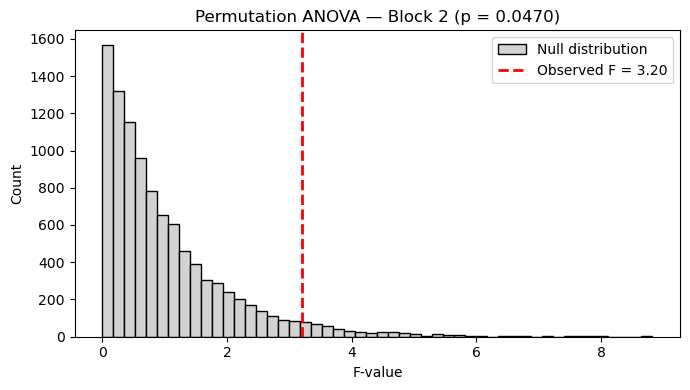

[i] Permutation histogram saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_permutation_ANOVA_hist.png
[i] Summary text → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_permutation_summary.txt


In [2]:
# =====================================================
# Block 2 — Permutation ANOVA (nonparametric validation)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pingouin import anova
from pathlib import Path

# ---------- Paths ----------
ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
IN_CSV = ROOT / "outputs" / "connectivity" / "block2" / "block2_posterior_alpha_summary.csv"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(IN_CSV)
df.rename(columns={"group": "group", "posterior_alpha_wpli": "posterior_alpha_wpli"}, inplace=True)
print(f"[i] Loaded {len(df)} entries from {IN_CSV.name}")
print(df.head(3))

# ---------- Permutation Function ----------
def perm_anova(df, n_perm=10000, seed=42):
    np.random.seed(seed)
    real_F = anova(data=df, dv="posterior_alpha_wpli", between="group", detailed=True)["F"].values[0]
    perm_F = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = df.copy()
        shuffled["group"] = np.random.permutation(shuffled["group"].values)
        perm_F[i] = anova(data=shuffled, dv="posterior_alpha_wpli", between="group", detailed=True)["F"].values[0]
    p_perm = np.mean(perm_F >= real_F)
    return real_F, p_perm, perm_F

# ---------- Run ----------
real_F, p_perm, perm_F = perm_anova(df, n_perm=10000)
print(f"[Permutation ANOVA] Observed F = {real_F:.3f}, p_perm = {p_perm:.4f}")

# ---------- Save ----------
np.save(SAVE_DIR / "block2_permutation_Fdist.npy", perm_F)
with open(SAVE_DIR / "block2_permutation_summary.txt", "w") as f:
    f.write(f"Observed F = {real_F:.3f}\n")
    f.write(f"Permutation p = {p_perm:.5f}\n")
    f.write(f"n_perm = {len(perm_F)}\n")

# ---------- Visualization ----------
plt.figure(figsize=(7, 4))
plt.hist(perm_F, bins=50, color="lightgray", edgecolor="black", label="Null distribution")
plt.axvline(real_F, color="red", linestyle="--", lw=2, label=f"Observed F = {real_F:.2f}")
plt.xlabel("F-value")
plt.ylabel("Count")
plt.title(f"Permutation ANOVA — Block 2 (p = {p_perm:.4f})")
plt.legend()
plt.tight_layout()
out_path = SAVE_DIR / "block2_permutation_ANOVA_hist.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[i] Permutation histogram saved → {out_path}")
print(f"[i] Summary text → {SAVE_DIR / 'block2_permutation_summary.txt'}")


In [4]:
# =====================================================
# Block 2 — Graph-Theoretic Metrics + 95 % CIs (v2 add-on)
# =====================================================
import networkx as nx
import pingouin as pg
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
WPLI_DIR = ROOT / "outputs" / "connectivity" / "block2"
SAVE_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load main scores ----------
df = pd.read_csv(WPLI_DIR / "block2_posterior_alpha_summary.csv")
print(f"[i] Loaded {len(df)} subjects for graph metrics")

# ---------- 1) Compute graph metrics per subject ----------
records = []
for _, row in df.iterrows():
    sid = row["subj"]
    npy_path = WPLI_DIR / f"sub-{int(sid):03d}_posterior_alpha_wpli.npy"
    if not npy_path.exists():
        print(f"[warn] Missing matrix for sub-{sid:03d}")
        continue

    W = np.load(npy_path)
    np.fill_diagonal(W, 0)
    G = nx.from_numpy_array(W)

    rec = {
        "subject": sid,
        "group": row["group"],
        "mean_degree": np.mean([d for _, d in G.degree(weight="weight")]),
        "global_eff": nx.global_efficiency(G),
        "clust_coeff": np.mean(list(nx.clustering(G, weight="weight").values()))
    }
    records.append(rec)

df_graph = pd.DataFrame(records)
graph_csv = SAVE_DIR / "block2_graph_metrics.csv"
df_graph.to_csv(graph_csv, index=False)
print(f"[i] Saved per-subject graph metrics → {graph_csv}")

# ---------- 2) ANOVA + pairwise for each graph metric ----------
for metric in ["mean_degree", "global_eff", "clust_coeff"]:
    aov = pg.anova(data=df_graph, dv=metric, between="group", detailed=True)
    pair = pg.pairwise_tests(
        data=df_graph,
        dv=metric,
        between="group",
        padjust="bonf",
        effsize="cohen"
    )
    aov.to_csv(SAVE_DIR / f"block2_{metric}_anova.csv", index=False)
    pair.to_csv(SAVE_DIR / f"block2_{metric}_pairwise.csv", index=False)
    print(f"[i] {metric}: ANOVA & pairwise tables saved")

# ---------- 3) 95 % bootstrap confidence intervals ----------
boot_n = 10000

# CI for group means (for figure captions)
ci_means = df.groupby("group")["posterior_alpha_wpli"].apply(
    lambda x: pg.compute_bootci(x, func="mean", n_boot=boot_n, seed=42)
)
ci_means.to_csv(SAVE_DIR / "block2_CI_means.csv")
print("[i] Saved 95 % CI for group means")

# CI for each pairwise Cohen's d
def boot_ci_d(x1, x2, n_boot=boot_n):
    return pg.compute_bootci(
        x1, func=lambda v: pg.compute_effsize(v, x2, eftype="cohen"),
        n_boot=n_boot, seed=42
    )

pairs = [("CN", "AD"), ("CN", "FTD"), ("AD", "FTD")]
ci_d = []
for g1, g2 in pairs:
    x1 = df.loc[df["group"] == g1, "posterior_alpha_wpli"]
    x2 = df.loc[df["group"] == g2, "posterior_alpha_wpli"]
    ci = boot_ci_d(x1, x2)
    ci_d.append({"contrast": f"{g1}-{g2}", "CI_low": ci[0], "CI_high": ci[1]})

ci_d_df = pd.DataFrame(ci_d)
ci_d_path = SAVE_DIR / "block2_CI_d.csv"
ci_d_df.to_csv(ci_d_path, index=False)
print(f"[i] Saved 95 % CI for effect sizes → {ci_d_path}")

print("[✓] Graph metrics + CI computation complete.")



[i] Loaded 88 subjects for graph metrics
[i] Saved per-subject graph metrics → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_graph_metrics.csv
[i] mean_degree: ANOVA & pairwise tables saved
[i] global_eff: ANOVA & pairwise tables saved
[i] clust_coeff: ANOVA & pairwise tables saved
[i] Saved 95 % CI for group means


/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/parametric.py:1008: RuntimeWarning: invalid value encountered in scalar divide
  fval = msbetween / mserror
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/parametric.py:1014: RuntimeWarning: invalid value encountered in scalar divide
  np2 = ssbetween / (ssbetween + sserror)  # = ssbetween / sstotal
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/effsize.py:803: RuntimeWarning: invalid value encountered in scalar divide
  d = (x.mean() - y.mean()) / poolsd
/Users/bohago/miniforge3/envs/eeg/lib/python3.11/site-packages/pingouin/effsize.py:803: RuntimeWarning: 

[i] Saved 95 % CI for effect sizes → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_CI_d.csv
[✓] Graph metrics + CI computation complete.


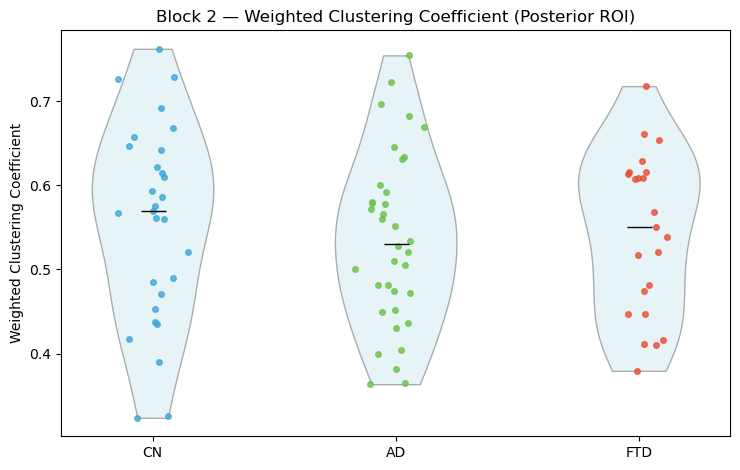

[✓] Figure saved → /Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025/outputs/connectivity/stats/block2/block2_clust_coeff_violin_match.png


In [5]:
# =====================================================
# Block 2 — Violin Plot of Clustering Coefficient
# =====================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/bohago/Desktop/neuro_analysis/EEG_resting-state_Jun_2025")
STATS_DIR = ROOT / "outputs" / "connectivity" / "stats" / "block2"

df_graph = pd.read_csv(STATS_DIR / "block2_graph_metrics.csv")

order = ["CN", "AD", "FTD"]
df_graph["group"] = pd.Categorical(df_graph["group"], categories=order, ordered=True)
df_graph = df_graph.sort_values("group")

groups = [g for g in order if g in set(df_graph["group"])]
data = [df_graph.loc[df_graph["group"] == g, "clust_coeff"].values for g in groups]

plt.figure(figsize=(7.5, 4.8))
parts = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)

# style like Block 1
for pc in parts["bodies"]:
    pc.set_facecolor("lightblue")
    pc.set_edgecolor("black")
    pc.set_alpha(0.3)

dot_colors = ["#3FA7D6", "#6CC24A", "#E94F37"]  # CN, AD, FTD
for i, (vals, c) in enumerate(zip(data, dot_colors), start=1):
    x = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(x, vals, "o", color=c, markersize=4, alpha=0.8)

medians = [np.median(v) if len(v) else np.nan for v in data]
plt.plot(range(1, len(groups) + 1), medians, marker="_", linestyle="none",
         color="black", markersize=18)

plt.xticks(range(1, len(groups) + 1), groups)
plt.ylabel("Weighted Clustering Coefficient")
plt.title("Block 2 — Weighted Clustering Coefficient (Posterior ROI)")
plt.grid(False)
plt.tight_layout()

out_path = STATS_DIR / "block2_clust_coeff_violin_match.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"[✓] Figure saved → {out_path}")
